geo_value,AK,AL,AR,AZ,CA,CO,CT,DC,DE,FL,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
time_value,,,,,,,,,,,,,,,,,,,,,
2020-01-01,0.000000,0.002705,0.000000,0.003082,0.001740,0.0,0.000000,0.0,0.000000,0.021437,...,0.0,0.000000,0.004123,0.011236,0.002278,0.0,0.001926,0.006764,0.0,0.0
2020-01-02,0.018405,0.002414,0.000000,0.002143,0.001770,0.0,0.000000,0.0,0.004666,0.012143,...,0.0,0.001071,0.004034,0.004478,0.001018,0.0,0.000869,0.002903,0.0,0.0
2020-01-03,0.011811,0.003075,0.000000,0.001849,0.001666,0.0,0.002293,0.0,0.005854,0.008719,...,0.0,0.001381,0.003927,0.002806,0.001311,0.0,0.000567,0.001854,0.0,0.0
2020-01-04,0.009677,0.002427,0.001766,0.001790,0.001445,0.0,0.001840,0.0,0.006839,0.007342,...,0.0,0.001662,0.003727,0.002285,0.001060,0.0,0.000442,0.001492,0.0,0.0
2020-01-05,0.008621,0.002051,0.002967,0.001779,0.001435,0.0,0.001568,0.0,0.005777,0.006486,...,0.0,0.001393,0.003351,0.001958,0.000899,0.0,0.000367,0.001291,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-07-28,0.000000,0.010643,0.005714,0.006006,0.007185,0.0,0.019759,0.0,0.000000,0.015117,...,0.0,0.001005,0.009276,0.004545,0.001437,0.0,0.008058,0.005146,0.0,0.0
2023-07-29,0.000000,0.010726,0.007109,0.004440,0.007179,0.0,0.016781,0.0,0.000000,0.014851,...,0.0,0.000000,0.008471,0.005671,0.001733,0.0,0.006815,0.004049,0.0,0.0
2023-07-30,0.000000,0.011150,0.000000,0.002154,0.006885,0.0,0.017442,0.0,0.000000,0.014446,...,0.0,0.000000,0.008878,0.000000,0.002091,0.0,0.005131,0.004717,0.0,0.0


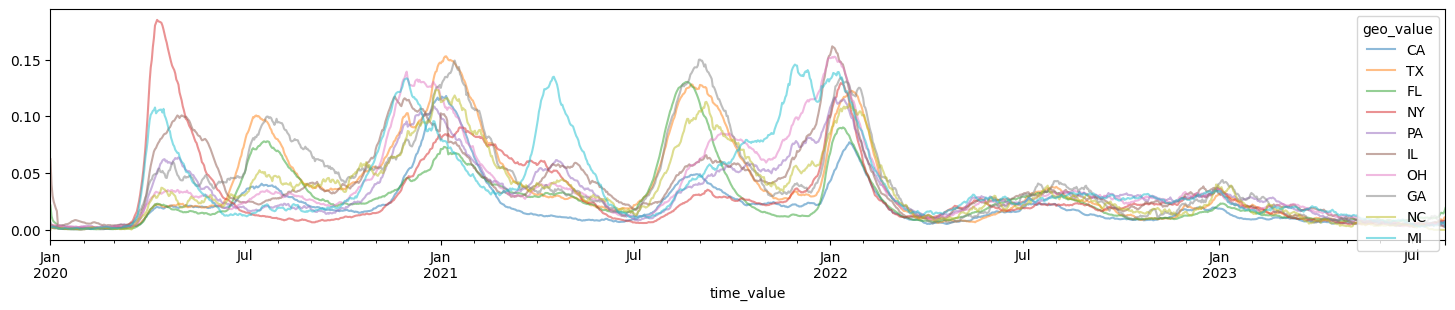

In [1]:
import pandas as pd
CHNGinpatient = pd.read_csv('/net/dali/home/mscbio/rul98/EpiPatch/rawData/covidcast-chng-7dav_inpatient_covid-2020-01-01-to-2023-08-01.csv', index_col = 0)
CHNGinpatient['geo_value'] = CHNGinpatient['geo_value'].str.upper()
CHNGinpatient['time_value'] = pd.to_datetime(CHNGinpatient['time_value'], format = '%Y-%m-%d')
CHNGinpatient = CHNGinpatient.pivot(values='value', columns='geo_value', index='time_value')
states = ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI',
          'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN',
          'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 
          'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT',
          'WA', 'WI', 'WV', 'WY']
CHNGinpatient = CHNGinpatient[states]

import numpy as np
CHNGinpatient[['CA', 'TX', 'FL', 'NY', 'PA', 'IL', 'OH', 'GA', 'NC', 'MI']].plot(figsize = (18, 3), alpha = 0.5);
CHNGinpatient

In [2]:
import pandas as pd

# Raw adjacency list in "state,neighbor1,neighbor2,..." format
raw = """AK
AL,MS,TN,GA,FL
AR,MO,TN,MS,LA,TX,OK
AZ,CA,NV,UT,CO,NM
CA,OR,NV,AZ
CO,WY,NE,KS,OK,NM,AZ,UT
CT,NY,MA,RI
DC,MD,VA
DE,MD,PA,NJ
FL,AL,GA
GA,FL,AL,TN,NC,SC
HI
IA,MN,WI,IL,MO,NE,SD
ID,MT,WY,UT,NV,OR,WA
IL,IN,KY,MO,IA,WI
IN,MI,OH,KY,IL
KS,NE,MO,OK,CO
KY,IN,OH,WV,VA,TN,MO,IL
LA,TX,AR,MS
MA,RI,CT,NY,NH,VT
MD,VA,WV,PA,DC,DE
ME,NH
MI,WI,IN,OH
MN,WI,IA,SD,ND
MO,IA,IL,KY,TN,AR,OK,KS,NE
MS,LA,AR,TN,AL
MT,ND,SD,WY,ID
NC,VA,TN,GA,SC
ND,MN,SD,MT
NE,SD,IA,MO,KS,CO,WY
NH,VT,ME,MA
NJ,DE,PA,NY
NM,AZ,UT,CO,OK,TX
NV,ID,UT,AZ,CA,OR
NY,NJ,PA,VT,MA,CT
OH,PA,WV,KY,IN,MI
OK,KS,MO,AR,TX,NM,CO
OR,CA,NV,ID,WA
PA,NY,NJ,DE,MD,WV,OH
RI,CT,MA
SC,GA,NC
SD,ND,MN,IA,NE,WY,MT
TN,KY,VA,NC,GA,AL,MS,AR,MO
TX,NM,OK,AR,LA
UT,ID,WY,CO,NM,AZ,NV
VA,NC,TN,KY,WV,MD,DC
VT,NY,NH,MA
WA,ID,OR
WI,MI,MN,IA,IL
WV,OH,PA,MD,VA,KY
WY,MT,SD,NE,CO,UT,ID"""

# Parse the raw adjacency list into a dictionary
adjacency = {}
for line in raw.strip().splitlines():
    parts = line.split(',')
    state = parts[0]
    neighbors = parts[1:]
    adjacency[state] = neighbors

# Build a square adjacency matrix, ensuring symmetry
matrix = {s: {t: 0 for t in states} for s in states}
for s, neighbors in adjacency.items():
    for t in neighbors:
        if s in states and t in states:
            matrix[s][t] = 1
            matrix[t][s] = 1  # ensure symmetry

adj_df = pd.DataFrame(matrix, index=states, columns=states)
adj_df

,AK,AL,AR,AZ,CA,CO,CT,DC,DE,FL,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
AK,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AL,0,0,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
AR,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
AZ,0,0,0,0,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
CA,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CO,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
CT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DC,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
DE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
FL,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
CHNGinpatient.to_csv('processed/CHNGinpatient.csv')
adj_df.to_csv('processed/CHNGinpatient_adj.csv')

geo_value,AK,AL,AR,AZ,CA,CO,CT,DC,DE,FL,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
time_value,,,,,,,,,,,,,,,,,,,,,
2020-01-01,0.000000,0.000000,0.000000,0.000009,0.000013,0.000051,0.000000,0.000000,0.000000,0.000008,...,0.000000,0.000000,0.000003,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2020-01-02,0.000000,0.000000,0.000000,0.000000,0.000016,0.000025,0.000000,0.000000,0.000000,0.000004,...,0.000000,0.000000,0.000006,0.000000,0.000000,0.000000,0.000000,0.000016,0.000000,0.000000
2020-01-03,0.000000,0.000000,0.000000,0.000000,0.000012,0.000000,0.000000,0.000000,0.000000,0.000004,...,0.000000,0.000000,0.000006,0.000000,0.000000,0.000000,0.000000,0.000015,0.000000,0.000000
2020-01-04,0.000000,0.000000,0.000000,0.000000,0.000012,0.000000,0.000000,0.000000,0.000038,0.000004,...,0.000000,0.000013,0.000012,0.000000,0.000011,0.000000,0.000000,0.000015,0.000000,0.000000
2020-01-05,0.000000,0.000000,0.000032,0.000000,0.000020,0.000000,0.000000,0.000000,0.000038,0.000007,...,0.000000,0.000013,0.000015,0.000000,0.000011,0.000000,0.000000,0.000016,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-07-28,0.004554,0.008207,0.006716,0.002424,0.004296,0.006861,0.002617,0.003670,0.002130,0.005895,...,0.008721,0.007733,0.005831,0.004361,0.005279,0.002058,0.002892,0.002485,0.008622,0.012118
2023-07-29,0.004197,0.008208,0.007134,0.002425,0.004142,0.007005,0.002543,0.003742,0.002030,0.005416,...,0.008911,0.008004,0.005653,0.004306,0.005338,0.002119,0.002737,0.002473,0.008557,0.011738
2023-07-30,0.003266,0.007815,0.007651,0.002260,0.003861,0.006789,0.002542,0.003808,0.001903,0.004779,...,0.007109,0.007786,0.005195,0.003997,0.005039,0.001846,0.002393,0.002401,0.007889,0.012134


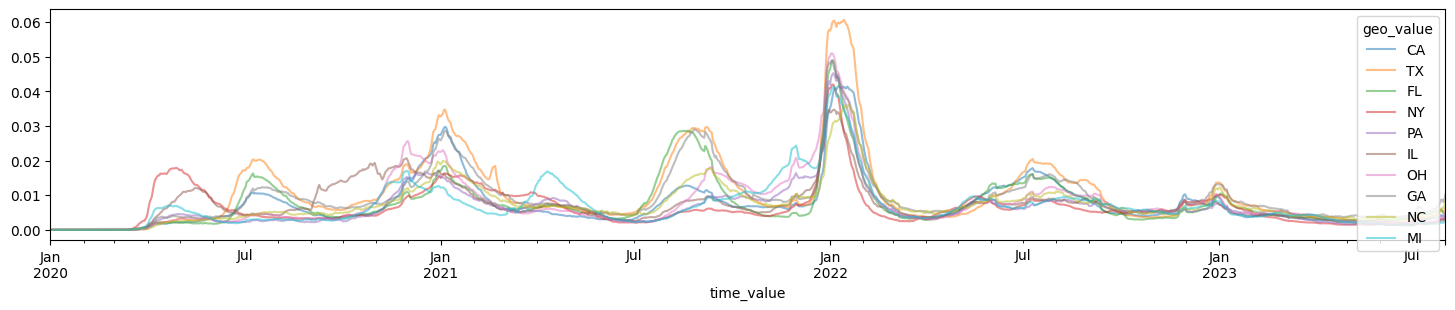

In [4]:
import pandas as pd
CHNGoutpatient = pd.read_csv('/net/dali/home/mscbio/rul98/EpiPatch/rawData/covidcast-chng-7dav_outpatient_covid-2020-01-01-to-2023-08-01.csv', index_col = 0)
CHNGoutpatient['geo_value'] = CHNGoutpatient['geo_value'].str.upper()
CHNGoutpatient['time_value'] = pd.to_datetime(CHNGoutpatient['time_value'], format = '%Y-%m-%d')
CHNGoutpatient = CHNGoutpatient.pivot(values='value', columns='geo_value', index='time_value')
states = ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI',
          'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN',
          'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 
          'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT',
          'WA', 'WI', 'WV', 'WY']
CHNGoutpatient = CHNGoutpatient[states]

import numpy as np
CHNGoutpatient[['CA', 'TX', 'FL', 'NY', 'PA', 'IL', 'OH', 'GA', 'NC', 'MI']].plot(figsize = (18, 3), alpha = 0.5);
CHNGoutpatient.to_csv('processed/CHNGoutpatient.csv')
adj_df.to_csv('processed/CHNGoutpatient_adj.csv')
CHNGoutpatient

geo_value,AK,AL,AR,AZ,CA,CO,CT,DC,DE,FL,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
time_value,,,,,,,,,,,,,,,,,,,,,
2020-03-01,NaN,NaN,NaN,NaN,0.239992,NaN,0.000000,NaN,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.541681,NaN,NaN,NaN
2020-03-02,NaN,NaN,NaN,1.000000,0.200978,NaN,0.000000,NaN,0.000000,0.054545,...,NaN,NaN,0.000000,NaN,NaN,NaN,0.408531,0.000000,NaN,NaN
2020-03-03,NaN,NaN,NaN,0.229730,0.164494,NaN,0.000000,NaN,0.000000,0.019131,...,NaN,0.125000,0.000000,0.000000,0.500000,NaN,0.367612,0.000000,NaN,NaN
2020-03-04,0.000000,NaN,0.000000,0.198142,0.140008,NaN,0.000000,NaN,0.000000,0.025693,...,NaN,0.125000,0.000000,0.000000,0.071429,NaN,0.247011,0.000000,NaN,NaN
2020-03-05,0.000000,NaN,0.000000,0.209590,0.121619,NaN,0.000000,NaN,0.000000,0.048782,...,NaN,0.199657,0.080000,0.000000,0.090164,NaN,0.200535,0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-11-28,0.050172,0.057188,0.082217,0.156253,0.033802,0.098401,0.057255,0.0227,0.086202,0.030564,...,0.174934,0.121070,0.072594,0.109977,0.083947,0.065258,NaN,0.134035,0.126759,0.079367
2021-11-29,0.048327,0.057289,0.083669,0.158335,0.033074,0.101209,0.061210,0.0239,0.088331,0.030990,...,0.174391,0.120906,0.071743,0.110675,0.084840,0.066853,NaN,0.135519,0.129285,0.078013
2021-11-30,0.047320,0.057643,0.079641,0.159825,0.033136,0.102237,0.065578,0.0238,0.091252,0.031458,...,0.172770,0.118585,0.071771,0.111746,0.087365,0.067977,NaN,0.138058,0.130746,0.077836


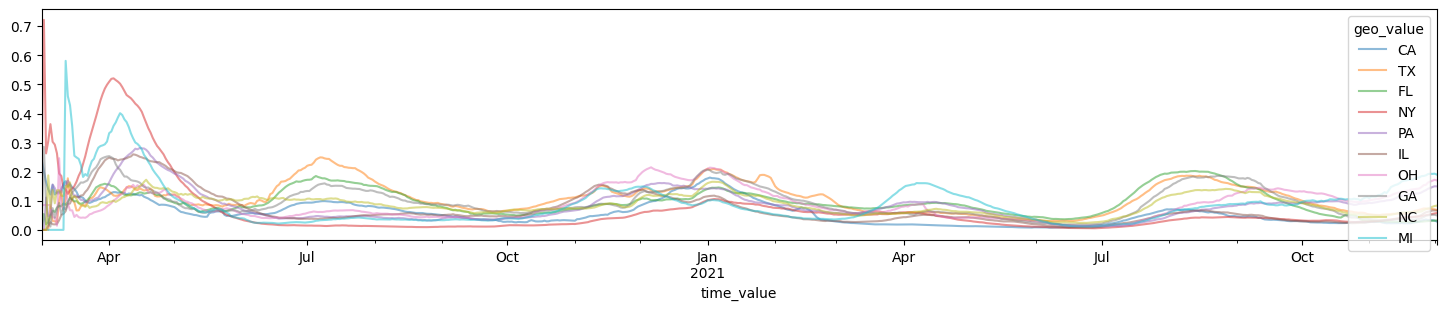

In [5]:
import pandas as pd
CANpositivity = pd.read_csv('/net/dali/home/mscbio/rul98/EpiPatch/rawData/covidcast-covid-act-now-pcr_specimen_positivity_rate-2020-03-01-to-2021-12-02.csv', index_col = 0)
CANpositivity['geo_value'] = CANpositivity['geo_value'].str.upper()
CANpositivity['time_value'] = pd.to_datetime(CANpositivity['time_value'], format = '%Y-%m-%d')
CANpositivity = CANpositivity.pivot(values='value', columns='geo_value', index='time_value')
states = ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI',
          'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN',
          'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 
          'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT',
          'WA', 'WI', 'WV', 'WY']
CANpositivity = CANpositivity[states]

import numpy as np
CANpositivity[['CA', 'TX', 'FL', 'NY', 'PA', 'IL', 'OH', 'GA', 'NC', 'MI']].plot(figsize = (18, 3), alpha = 0.5);
CANpositivity.to_csv('processed/CANpositivity.csv')
adj_df.to_csv('processed/CANpositivity_adj.csv')
CANpositivity

geo_value,AK,AL,AR,AZ,CA,CO,CT,DC,DE,FL,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
time_value,,,,,,,,,,,,,,,,,,,,,
2020-02-01,0.083479,0.035638,0.148431,0.129299,0.169873,0.154064,0.143501,0.000000,0.000000,0.141296,...,0.000000,0.235429,0.188901,0.031368,0.234884,0.000000,0.055272,0.100114,0.000000,0.000000
2020-02-02,0.125133,0.035638,0.148431,0.129299,0.169046,0.160143,0.143199,0.000000,0.000000,0.140770,...,0.000000,0.235252,0.188551,0.031368,0.234884,0.000000,0.052098,0.100114,0.000000,0.000000
2020-02-03,0.153689,0.035638,0.148431,0.129299,0.168328,0.157627,0.142885,0.000000,0.000000,0.140295,...,0.000000,0.235079,0.188260,0.031368,0.234884,0.000000,0.049600,0.100114,0.000000,0.000000
2020-02-04,0.120818,0.035638,0.148431,0.129299,0.168300,0.155274,0.142577,0.000000,0.000000,0.139883,...,0.000000,0.234917,0.188029,0.031368,0.234884,0.000000,0.048741,0.100114,0.000000,0.000000
2020-02-05,0.031810,0.035638,0.148431,0.129299,0.167762,0.153154,0.142289,0.000000,0.000000,0.140069,...,0.000000,0.234772,0.188736,0.031368,0.234884,0.000000,0.048741,0.100114,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-28,0.000000,0.840606,1.368141,0.418345,0.240975,0.565560,0.896466,0.242483,0.416317,0.144979,...,0.231265,1.085687,0.310763,0.275298,0.573220,0.212706,0.115391,0.601600,0.765708,0.315973
2025-12-29,0.000000,0.757984,1.139539,0.372169,0.221078,0.491009,0.766305,0.178172,0.387241,0.135355,...,0.373123,0.959888,0.285847,0.235752,0.523154,0.261780,0.103311,0.516079,0.706272,0.364726
2025-12-30,0.000000,0.637923,0.920464,0.312056,0.196326,0.397693,0.644814,0.121430,0.393496,0.122796,...,0.361299,0.806517,0.252595,0.192423,0.452996,0.259116,0.084610,0.440064,0.723524,0.297591


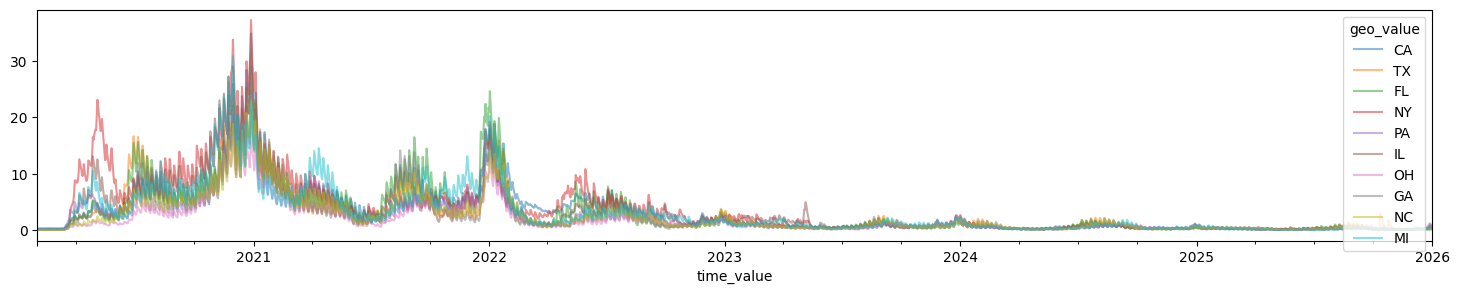

In [6]:
import pandas as pd
DVcli = pd.read_csv('/net/dali/home/mscbio/rul98/EpiPatch/rawData/covidcast-doctor-visits-smoothed_cli-2020-02-01-to-2026-01-01.csv', index_col = 0)
DVcli['geo_value'] = DVcli['geo_value'].str.upper()
DVcli['time_value'] = pd.to_datetime(DVcli['time_value'], format = '%Y-%m-%d')
DVcli = DVcli.pivot(values='value', columns='geo_value', index='time_value')
states = ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI',
          'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN',
          'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 
          'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT',
          'WA', 'WI', 'WV', 'WY']
DVcli = DVcli[states]

import numpy as np
DVcli[['CA', 'TX', 'FL', 'NY', 'PA', 'IL', 'OH', 'GA', 'NC', 'MI']].plot(figsize = (18, 3), alpha = 0.5);
DVcli.to_csv('processed/DVcli.csv')
adj_df.to_csv('processed/DVcli_adj.csv')
DVcli

geo_value,AK,AL,AR,AZ,CA,CO,CT,DC,DE,FL,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
time_value,,,,,,,,,,,,,,,,,,,,,
2020-12-16,14.000000,338.571429,150.000000,472.000000,1927.714286,222.285714,138.714286,29.000000,51.428571,767.142857,...,32.857143,347.428571,1176.857143,79.428571,217.428571,4.714286,100.000000,343.714286,87.714286,26.571429
2020-12-17,14.285714,347.714286,154.142857,465.285714,1997.142857,211.428571,139.857143,30.285714,51.714286,780.000000,...,31.142857,349.000000,1186.857143,78.428571,219.571429,5.000000,100.571429,332.000000,84.571429,24.285714
2020-12-18,13.285714,303.857143,153.285714,473.857143,2066.285714,205.285714,130.571429,29.428571,51.000000,795.428571,...,32.428571,350.428571,1213.857143,88.857143,225.857143,5.571429,99.285714,326.142857,82.571429,23.714286
2020-12-19,13.142857,347.428571,146.714286,464.571429,2091.428571,198.000000,108.000000,30.428571,47.571429,779.714286,...,30.571429,342.714286,1127.857143,90.000000,214.285714,5.857143,101.428571,317.571429,80.428571,25.285714
2020-12-20,10.571429,349.285714,146.285714,456.142857,2113.714286,185.285714,93.714286,27.714286,44.000000,778.857143,...,30.142857,337.285714,1277.285714,90.142857,217.714286,6.000000,99.000000,306.571429,78.285714,24.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-11,8.551020,61.795918,23.755102,50.918367,416.551020,40.755102,62.000000,13.183673,14.938776,285.693878,...,13.326531,63.000000,313.040816,20.489796,91.102041,5.571429,56.102041,68.734694,27.836735,3.102041
2023-02-12,8.938776,62.102041,23.551020,51.183673,420.081633,41.551020,61.142857,13.122449,14.673469,282.510204,...,13.693878,60.571429,314.551020,21.326531,89.448980,5.714286,57.163265,67.918367,26.795918,3.448980
2023-02-13,9.326531,62.408163,23.346939,51.448980,423.612245,42.346939,60.285714,13.061224,14.408163,279.326531,...,14.061224,58.142857,316.061224,22.163265,87.795918,5.857143,58.224490,67.102041,25.755102,3.795918


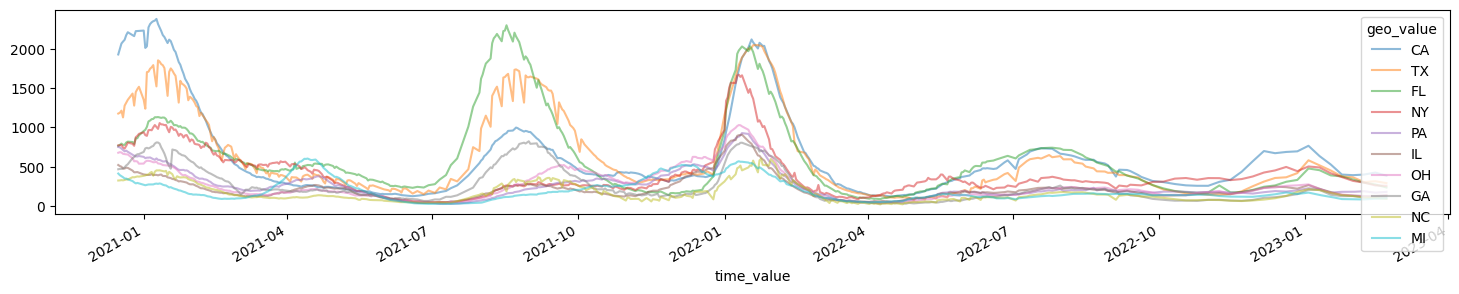

In [7]:
import pandas as pd
CPRadmissions = pd.read_csv('covidcast-dsew-cpr-confirmed_admissions_covid_1d_7dav-2020-12-16-to-2023-02-21.csv', index_col = 0)
CPRadmissions['geo_value'] = CPRadmissions['geo_value'].str.upper()
CPRadmissions['time_value'] = pd.to_datetime(CPRadmissions['time_value'], format = '%Y-%m-%d')
CPRadmissions = CPRadmissions.pivot(values='value', columns='geo_value', index='time_value')
states = ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI',
          'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN',
          'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 
          'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT',
          'WA', 'WI', 'WV', 'WY']
CPRadmissions = CPRadmissions[states]

import numpy as np
CPRadmissions[['CA', 'TX', 'FL', 'NY', 'PA', 'IL', 'OH', 'GA', 'NC', 'MI']].plot(figsize = (18, 3), alpha = 0.5);
CPRadmissions.to_csv('processed/CPRadmissions.csv')
adj_df.to_csv('processed/CPRadmissions_adj.csv')
CPRadmissions

geo_value,AK,AL,AR,AZ,CA,CO,CT,DC,DE,FL,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
time_value,,,,,,,,,,,,,,,,,,,,,
2020-01-26,NaN,70.0,64.0,87.0,488.0,52.0,53.0,11.0,14.0,280.0,...,10.0,140.0,306.0,20.0,82.0,NaN,78.0,68.0,35.0,NaN
2020-02-02,NaN,71.0,59.0,90.0,519.0,61.0,44.0,10.0,NaN,322.0,...,18.0,141.0,322.0,30.0,73.0,NaN,81.0,58.0,39.0,14.0
2020-02-09,0.0,83.0,43.0,108.0,508.0,57.0,47.0,13.0,NaN,301.0,...,14.0,131.0,346.0,19.0,67.0,NaN,96.0,89.0,45.0,NaN
2020-02-16,NaN,73.0,65.0,91.0,536.0,48.0,49.0,NaN,15.0,307.0,...,13.0,107.0,316.0,22.0,76.0,NaN,75.0,71.0,37.0,NaN
2020-02-23,NaN,78.0,39.0,95.0,506.0,73.0,68.0,NaN,12.0,301.0,...,13.0,131.0,341.0,36.0,83.0,14.0,92.0,71.0,44.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30,NaN,59.0,48.0,77.0,386.0,47.0,56.0,NaN,11.0,303.0,...,16.0,113.0,242.0,14.0,65.0,NaN,54.0,57.0,29.0,NaN
2025-12-07,NaN,63.0,36.0,67.0,399.0,53.0,61.0,NaN,12.0,268.0,...,10.0,118.0,269.0,27.0,78.0,NaN,75.0,50.0,39.0,NaN
2025-12-14,NaN,85.0,53.0,84.0,441.0,60.0,61.0,NaN,11.0,265.0,...,14.0,110.0,290.0,15.0,78.0,NaN,69.0,49.0,38.0,NaN


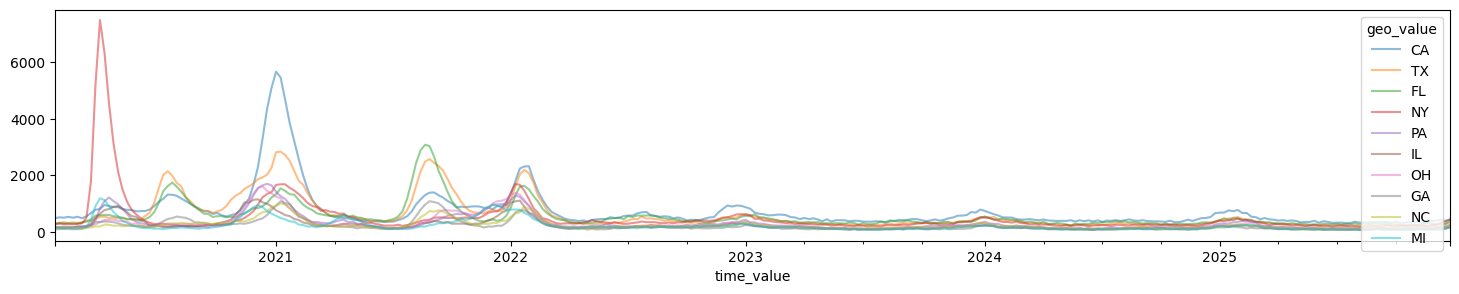

In [8]:
import pandas as pd
from epiweeks import Week
NCHSdeaths = pd.read_csv('/net/dali/home/mscbio/rul98/EpiPatch/rawData/covidcast-nchs-mortality-deaths_pneumonia_or_flu_or_covid_incidence_num-202005-to-202553.csv', index_col = 0)
NCHSdeaths['geo_value'] = NCHSdeaths['geo_value'].str.upper()

s = NCHSdeaths['time_value'].astype(str).str.zfill(6)
year = s.str[:4].astype(int)
week = s.str[4:].astype(int)

# startdate() gives the Sunday at the start of the CDC/MMWR epiweek
NCHSdeaths['time_value'] = pd.to_datetime(
    [Week(y, w).startdate() for y, w in zip(year, week)]
)

NCHSdeaths = NCHSdeaths.pivot(values='value', columns='geo_value', index='time_value')
states = ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI',
          'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN',
          'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 
          'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT',
          'WA', 'WI', 'WV', 'WY']
NCHSdeaths = NCHSdeaths[states]

import numpy as np
NCHSdeaths[['CA', 'TX', 'FL', 'NY', 'PA', 'IL', 'OH', 'GA', 'NC', 'MI']].plot(figsize = (18, 3), alpha = 0.5);
NCHSdeaths.to_csv('processed/NCHSdeaths.csv')
adj_df.to_csv('processed/NCHSdeaths_adj.csv')
NCHSdeaths